In [1]:
from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import numpy as np
import pickle 
import brian2 as b2
import brian2hears as b2h
import matplotlib.pyplot as plt
from preprocess import preprocessing as pre
import os.path
from os import path
%matplotlib inline

In [2]:
import IPython

for sound in testSounds:
    IPython.display.display(IPython.display.Audio(sound+".wav"))

NameError: name 'testSounds' is not defined

In [ ]:
testSounds = ["0a196374_nohash_1","0a2b400e_nohash_0","0a2b400e_nohash_1","0a2b400e_nohash_2","0a2b400e_nohash_3","0a9f9af7_nohash_0","0a9f9af7_nohash_1","0a9f9af7_nohash_2","00f0204f_nohash_0","00f0204f_nohash_1"]
trainingSounds = ["0a196374_nohash_1"]
  

trainingSpect = pre.spectArray(trainingSounds[0], cfN=50)

pre.spectShow(trainingSpect[:,5000:7000]) #, zoom_x=5000, zoom_y=7000)
trainingIndex = [6000]
testingIndex = [6000, 3000, 4500, 3900, 3900, 5500, 8500, 6200, 2500, 3000]
scale = 15 #changed because we're normalising in a different way
#I changed scale from 15 to 10 because 16 resulted in a KeyError: 21
# normalising 0 to 1, then multiply by scale (15)
# this is to scale each individual sample
range_f = 100
step_f = 10
#sample the odors


trainingOdors = pre.chooseSound(trainingSpect, range_f, step_f, trainingIndex[0], scale)
#trainingOdors = trainingOdors.tolist()
"""
trainingOdors = trainingSpect[:,trainingIndex[0]:trainingIndex[0]+range_f:step_f]
#flatten list (np function) above to 1 row and 110 samples
#trainingOdors = trainingOdors.flatten()
trainingOdors = trainingOdors.reshape((1,-1))
#scale the training samples
trainingOdors *= scale/trainingOdors.max()
trainingOdors = trainingOdors.astype(np.int64)
# function for training the network
"""
testOdors = np.array([])

index = 0
for sound in testSounds:
    testingSpect = pre.spectArray(sound, cfN=50)
    #testingOdors.append(testingSpect[:,trainingIndex[0]:trainingIndex[0]+range_f:step_f])
    #testOdors = np.append([testOdors],[pre.chooseSound(testingSpect, range_f, step_f, trainingIndex[0], scale)])
    if testOdors.shape[0] == 0:
        testOdors = pre.chooseSound(testingSpect, range_f, step_f, testingIndex[index],scale)
    else:
        testOdors = np.concatenate((testOdors,pre.chooseSound(testingSpect, range_f, step_f, testingIndex[index],scale)))
    index +=1
    #indices_list.append()
#testOdors = np.insert([testOdors],[0]*500,[pre.chooseSound(testingSpect, range_f, step_f, trainingIndex[0], scale)])

#testOdors = testOdors.astype(np.int64)
#testOdors = testOdors.tolist()

In [5]:
trainingOdors

array([[ 2,  2,  2,  2,  1,  0,  1,  1,  2,  2,  4,  4,  3,  1,  1,  3,
         4,  4,  4,  4,  5,  2,  3,  6,  7,  8,  8,  6,  4,  1, 10, 11,
        11, 11,  9,  5,  5,  9, 11, 11, 10,  6,  6, 10, 12, 12, 12, 11,
         8,  2,  9, 10, 10,  9,  7,  2,  5,  8, 10, 10,  7,  7,  5,  1,
         4,  6,  7,  7,  7,  5,  7,  5,  2,  6,  7,  6,  4,  0,  2,  3,
         4,  6,  9,  8,  4,  5,  8,  6,  1,  6, 11, 10,  4,  8, 10,  9,
         3, 10, 10,  7,  0,  9, 10,  7,  6,  9,  9,  6,  7, 10,  9,  7,
         5,  8,  6,  1,  4,  4,  4,  5,  8,  6, 10,  5,  8,  7,  6,  8,
         4,  9,  7, 12,  6, 12, 10, 10, 12,  4, 13,  9, 14,  4, 14, 10,
        13, 13, 10, 15,  6, 14,  8, 13,  5, 13, 11, 11, 13,  5, 13,  9,
        11,  5, 10,  9,  9, 10,  4,  9,  6,  8,  6,  8,  7,  6,  6,  3,
         3,  1,  4,  4,  5,  3,  2,  0,  1,  3,  1,  6,  3,  7,  1,  0,
         3,  1,  2,  1,  1,  4,  3,  6,  0,  3,  1,  0,  1,  3,  3,  4,
         5,  2,  2,  0,  0,  2,  2,  1,  4,  1,  4,  2,  0,  0, 

Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


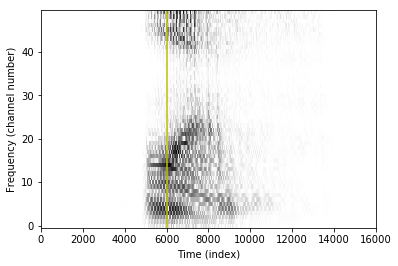

Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


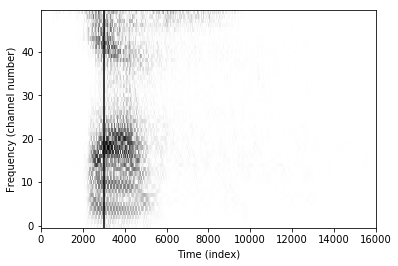

Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


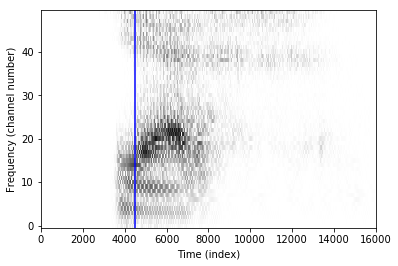

Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


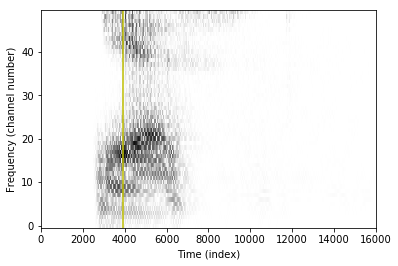

Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


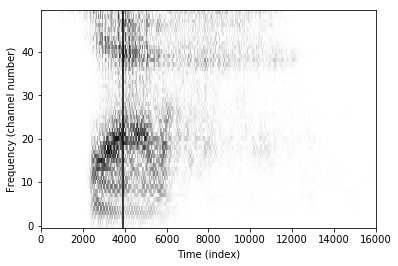

Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


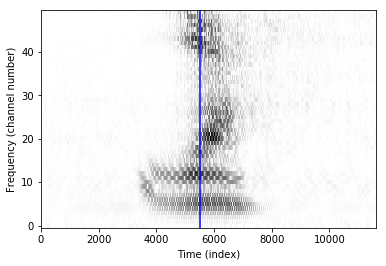

Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


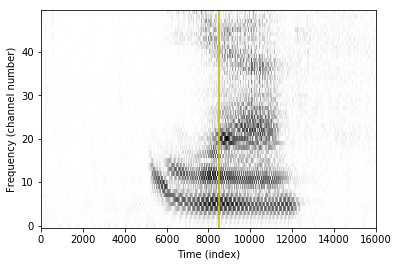

Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


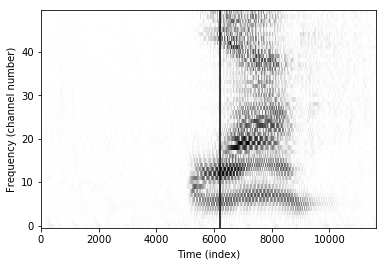

Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


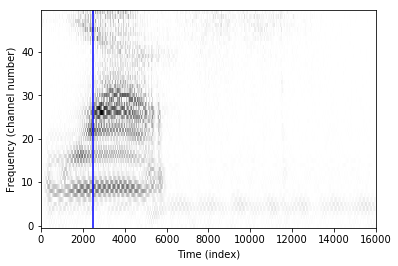

Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


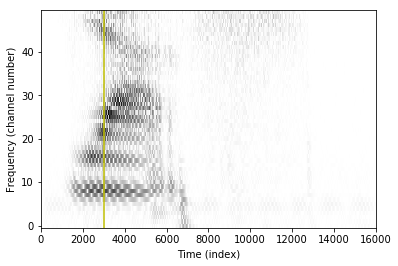

In [7]:
colors = ['y','k','b','y','k','b','y','k','b','y']
for sound in testSounds:
    pre.spectShow(pre.spectArray(sound,cfN=50))
    plt.axvline(x=testingIndex[testSounds.index(sound)], c=colors[testSounds.index(sound)])
    plt.show()


# Leaky integrate-and-fire model with noise and refractoriness


In [3]:
from lib import epl 

"""
trainingOdors = X[:,xcoords[0]].T/X.max()*scale
trainingOdors = [trainingOdors.astype(np.int64)]


testOdors = X[:,xcoords[1:10]].T/X.max()*scale
testOdors = testOdors.astype(np.int64)

"""
nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 

#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1, nGammaPerOdor = 5);  #default value is 5, may experiment with 10
    epl.GClayer.invokeNeurogenesis();
    sniff(trainingOdors[i], learn_flag=0);

#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0); 
    if(i==len(testOdors)-1):
        print(str(i+1) + " odors tested"); 

#Readout
sMatrix = readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  
#print out sMatrix (in readout library)
#Plots
plots.plotFigure3b(epl.gammaCode); 
plots.plotFigure3d(sMatrix); 



NameError: name 'trainingOdors' is not defined

In [12]:
len(testOdors[0])

100

In [22]:
len(testOdors)

10

In [7]:
X.shape

(100L, 27000L)

In [11]:
len(trainingOdors[0])

100